In [1]:
import datetime
print("Latest Changes:", datetime.datetime.now())

Latest Changes: 2026-04-14 21:50:14.622385


# Point 3

### Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

In [3]:
sensor = pd.read_csv("data/sensor_hrv_filtered.csv")
survey = pd.read_csv("data/survey.csv")

In [4]:
# Cleaning Survey
survey["PHQ9"] = survey[["PHQ9_1","PHQ9_2","PHQ9_F"]].mean(axis=1)
survey["GAD7"] = survey[["GAD7_1","GAD7_2","GAD7_F"]].mean(axis=1)
survey["ISI"]  = survey[["ISI_1","ISI_2","ISI_F"]].mean(axis=1)

survey_clean = survey[["deviceId","PHQ9","GAD7","ISI","MEQ"]]

In [5]:
# Cleaning Sensor
sensor["datetime"] = pd.to_datetime(sensor["ts_start"], unit="ms")
sensor_clean = sensor[sensor["missingness_score"] <= 0.3]

### Necessary Functions

In [6]:
def safe_ami(ts, max_lag=50, bins=20):
    if len(ts) < 50:
        print("  TS too short for AMI")
        return None

    if np.std(ts) == 0:
        print("  Constant TS")
        return None

    try:
        hist = np.histogram(ts, bins=bins)[1]
        ts_binned = np.digitize(ts, hist)

        ami_values = []
        for lag in range(1, max_lag):
            x = ts_binned[:-lag]
            y = ts_binned[lag:]

            if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
                ami_values.append(0)
                continue

            ami_values.append(mutual_info_score(x, y))

        return np.array(ami_values)

    except Exception as e:
        print("  AMI ERROR:", e)
        return None

In [7]:
def first_local_minimum(arr):
    if arr is None or len(arr) < 3:
        return 1
    for i in range(1, len(arr)-1):
        if arr[i] < arr[i-1] and arr[i] < arr[i+1]:
            return i + 1
    return np.argmin(arr) + 1

In [8]:
def compute_fnn(ts, tau, max_dim=8, rtol=10):
    fnn_vals = []
    N = len(ts)

    for m in range(1, max_dim):
        M = N - (m+1)*tau
        if M <= 10:
            break

        emb_m = np.array([ts[i:i+m*tau:tau] for i in range(M)])
        emb_m1 = np.array([ts[i:i+(m+1)*tau:tau] for i in range(M)])

        nbrs = NearestNeighbors(n_neighbors=2).fit(emb_m)
        dist, idx = nbrs.kneighbors(emb_m)

        fnn = 0
        for i in range(M):
            nn = idx[i,1]
            d_m = dist[i,1]
            d_m1 = np.linalg.norm(emb_m1[i] - emb_m1[nn])

            if d_m > 0 and (d_m1 - d_m)/d_m > rtol:
                fnn += 1

        fnn_vals.append(fnn / M)

    return fnn_vals

In [9]:
def takens(ts, m, tau):
    N = len(ts)
    M = N - (m-1)*tau
    return np.array([ts[i:i+m*tau:tau] for i in range(M)])

##### RQA functions

In [10]:
def recurrence_matrix(emb, eps):
    D = squareform(pdist(emb))
    R = (D < eps).astype(int)
    return R

In [11]:
def choose_eps(emb, target_rr=0.03):
    D = pdist(emb)
    eps = np.quantile(D, target_rr)
    return eps

In [12]:
def recurrence_rate(R):
    return np.mean(R)

In [13]:
def determinism(R, l_min=2):
    N = R.shape[0]
    det_points = 0
    total_rec = np.sum(R)

    for k in range(-N+1, N):
        diag = np.diag(R, k=k)

        length = 0
        for val in diag:
            if val == 1:
                length += 1
            else:
                if length >= l_min:
                    det_points += length
                length = 0

        if length >= l_min:
            det_points += length

    return det_points / (total_rec + 1e-8)

In [14]:
def complexity(emb):
    nbrs = NearestNeighbors(n_neighbors=2).fit(emb)
    d, _ = nbrs.kneighbors(emb)
    return np.mean(d[:,1])

### Main Loop and Results

In [15]:
participants = sensor_clean["deviceId"].unique()
results = []

for pid in participants:

    print("\n==============================")
    print("PID:", pid)

    df = sensor_clean[sensor_clean["deviceId"] == pid].copy()
    df = df.sort_values("datetime")

    ts = df["rmssd"].dropna().values

    print("raw ts length:", len(ts))

    if len(ts) < 100:
        print("SKIP: too short")
        continue

    ts = (ts - np.mean(ts)) / (np.std(ts) + 1e-8)
    print("ts standardized OK")

    # --- AMI → tau
    ami_vals = safe_ami(ts)
    tau = first_local_minimum(ami_vals)
    print("tau:", tau)

    # --- FNN → m
    fnn_vals = compute_fnn(ts, tau)

    if len(fnn_vals) == 0:
        print("SKIP: FNN failed")
        continue

    m = next((i+1 for i,v in enumerate(fnn_vals) if v < 0.01), 3)
    print("embedding dim m:", m)

    # --- Embedding
    emb = takens(ts, m, tau)
    print("embedding shape:", emb.shape)

    # --- RQA
    eps = choose_eps(emb)
    print("epsilon:", eps)

    R = recurrence_matrix(emb, eps)

    rr = recurrence_rate(R)
    det = determinism(R)

    print("RR:", rr)
    print("DET:", det)

    # --- Additional metric
    comp = complexity(emb)
    print("complexity:", comp)

    meq = survey_clean.loc[survey_clean["deviceId"] == pid, "MEQ"].values[0]

    results.append([pid, comp, det, rr, emb])



PID: ab60
raw ts length: 981
ts standardized OK
tau: 2
embedding dim m: 6
embedding shape: (971, 6)
epsilon: 1.178460424334249
RR: 0.031000985319900174
DET: 0.10506688562725201
complexity: 0.7945608929481655

PID: am77
raw ts length: 257
ts standardized OK
tau: 2
embedding dim m: 5
embedding shape: (249, 5)
epsilon: 0.8413565219925053
RR: 0.03391880776116514
DET: 0.18497384688452226
complexity: 0.7075002128080718

PID: av54
raw ts length: 384
ts standardized OK
tau: 4
embedding dim m: 4
embedding shape: (372, 4)
epsilon: 0.8713118437995255
RR: 0.032619377962770264
DET: 0.21754541426624383
complexity: 0.5470609553464592

PID: ba30
raw ts length: 921
ts standardized OK
tau: 4
embedding dim m: 5
embedding shape: (905, 5)
epsilon: 1.1324949883163196
RR: 0.031072311590000304
DET: 0.17246257220316222
complexity: 0.6476315155258988

PID: bp16
raw ts length: 488
ts standardized OK
tau: 6
embedding dim m: 5
embedding shape: (464, 5)
epsilon: 0.9221571522453127
RR: 0.03209534780023781
DET: 0.18

In [16]:
results_df = pd.DataFrame(results, columns=["deviceId","complexity","DET","RR","emb"])
results_df = results_df.merge(survey_clean, on="deviceId")

In [17]:
print("\n=== HYPOTHESIS TEST ===")

print("\n--- Complexity ---")
print("PHQ9:", spearmanr(results_df["complexity"], results_df["PHQ9"]))
print("GAD7:", spearmanr(results_df["complexity"], results_df["GAD7"]))
print("ISI:",  spearmanr(results_df["complexity"], results_df["ISI"]))

print("\n--- DET ---")
print("PHQ9:", spearmanr(results_df["DET"], results_df["PHQ9"]))
print("GAD7:", spearmanr(results_df["DET"], results_df["GAD7"]))
print("ISI:",  spearmanr(results_df["DET"], results_df["ISI"]))

print("\n--- RR ---")
print("PHQ9:", spearmanr(results_df["RR"], results_df["PHQ9"]))
print("GAD7:", spearmanr(results_df["RR"], results_df["GAD7"]))
print("ISI:",  spearmanr(results_df["RR"], results_df["ISI"]))


=== HYPOTHESIS TEST ===

--- Complexity ---
PHQ9: SignificanceResult(statistic=0.20199644982076873, pvalue=0.16856697105214674)
GAD7: SignificanceResult(statistic=0.16220090225661818, pvalue=0.27069988528270844)
ISI: SignificanceResult(statistic=0.13108880197137335, pvalue=0.374481206916216)

--- DET ---
PHQ9: SignificanceResult(statistic=0.2911925127464717, pvalue=0.0446422797639567)
GAD7: SignificanceResult(statistic=0.3456722658044539, pvalue=0.016108009174293243)
ISI: SignificanceResult(statistic=0.3701873914825402, pvalue=0.00960164797095437)

--- RR ---
PHQ9: SignificanceResult(statistic=0.2118406494485445, pvalue=0.14833134341355161)
GAD7: SignificanceResult(statistic=0.33700046235495756, pvalue=0.019168606971201114)
ISI: SignificanceResult(statistic=0.21677982496674497, pvalue=0.13888180385349608)


# Point 4

In [19]:
def label_meq(x):
    if x >= 59:
        return "morning"
    elif x <= 41:
        return "evening"
    else:
        return "neutral"

results_df["chronotype"] = results_df["MEQ"].apply(label_meq)

<Axes: title={'center': 'DET'}, xlabel='chronotype'>

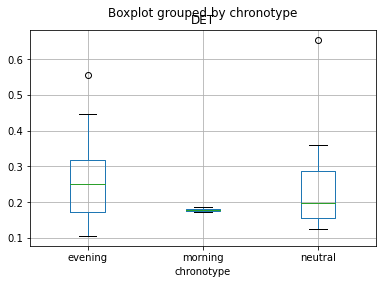

In [20]:
results_df.groupby("chronotype")[["DET","RR","complexity"]].mean()
results_df.boxplot(column="DET", by="chronotype")

In [21]:
results_df["chronotype"].value_counts()

evening    23
neutral    23
morning     2
Name: chronotype, dtype: int64